# FLOOD RISK PREDICTION

## 1.Problem Definition
Flooding is one of the most devastating natural disasters, often resulting in loss of life, displacement, and destruction of property and infrastructure. Accurate and timely flood risk prediction is critical for disaster preparedness, urban planning, and climate resilience efforts. 

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## 2. Data Collection & Understanding
What data do we have?
Let's load the data and take a look at its structure.

In [2]:
# Load the data
df = pd.read_csv('data/flood.csv')

# Display the first few rows
#df.head(20)


## 3. Data Preprocessing
### Cleaning and preparing the data
We'll check for missing values, data types, and basic statistics. We'll also encode categorical variables if necessary.

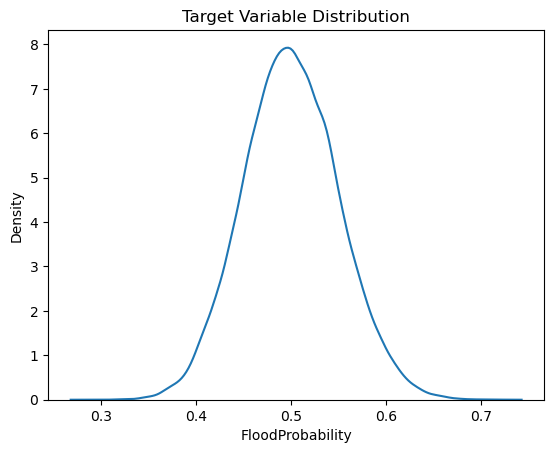

In [3]:
#Check for missing values and data types
#print(df.info())

# Display basic statistics
#print("THE DESCRIPTIVE STATISTICS OF THE DATASET:\n")
#print(df.describe())

# Check missing values
#print("MISSING VALUES:\n", df.isnull().sum())

# Verify feature distributions
#df.hist(figsize=(20, 15), bins=10)
#plt.tight_layout()
#plt.show()

# Check for class imbalance in target (though continuous)
sns.kdeplot(df['FloodProbability'])
plt.title('Target Variable Distribution')
plt.show()

In [6]:
import smogn

# Ensure all columns are float64 for compatibility with smogn
df = df.astype('float32')

# Drop rows with NaN or infinite values
#df = df.replace([np.inf, -np.inf], np.nan)
#df = df.dropna()

# 1. Define your custom relevance function settings
# (relevance_config is already defined in the notebook)
relevance_config = np.array([
    [0.4, 1.0, 0.5],
    [0.5, 0.0, 0.5],
    [0.6, 1.0, 0.5]
])

# 2. Apply SMOGN with custom relevance
df_smogn = smogn.smoter(
    data=df,
    y='FloodProbability',
    rel_thres=0.8,
    rel_method='manual',
    rel_ctrl_pts_rg=relevance_config,
    samp_method='extreme',
    k=3
)

print("Original shape:", df.shape)
print("SMOGN-balanced shape:", df_smogn.shape)

# Use the new dataframe for training
df = df_smogn.copy()


dist_matrix:  21%|##        | 756/3634 [04:58<18:54,  2.54it/s]


KeyboardInterrupt: 

In [ ]:
sns.kdeplot(df['FloodProbability'])
plt.title('Target Variable Distribution')
plt.show()

In [12]:
# ====== ADVANCED FEATURE ENGINEERING ======
# 1. Interaction terms (domain knowledge-based)
df['Monsoon_Drainage_Interaction'] = df['MonsoonIntensity'] * df['DrainageSystems']
df['Urbanization_Encroachment'] = df['Urbanization'] * df['Encroachments']

# 2. Climate vulnerability index
climate_features = ['ClimateChange', 'CoastalVulnerability', 'WetlandLoss']
df['ClimateVulnerability'] = df[climate_features].mean(axis=1)

# 3. Infrastructure quality composite
infra_features = ['RiverManagement', 'DamsQuality', 'DrainageSystems']
df['InfrastructureQuality'] = df[infra_features].mean(axis=1)


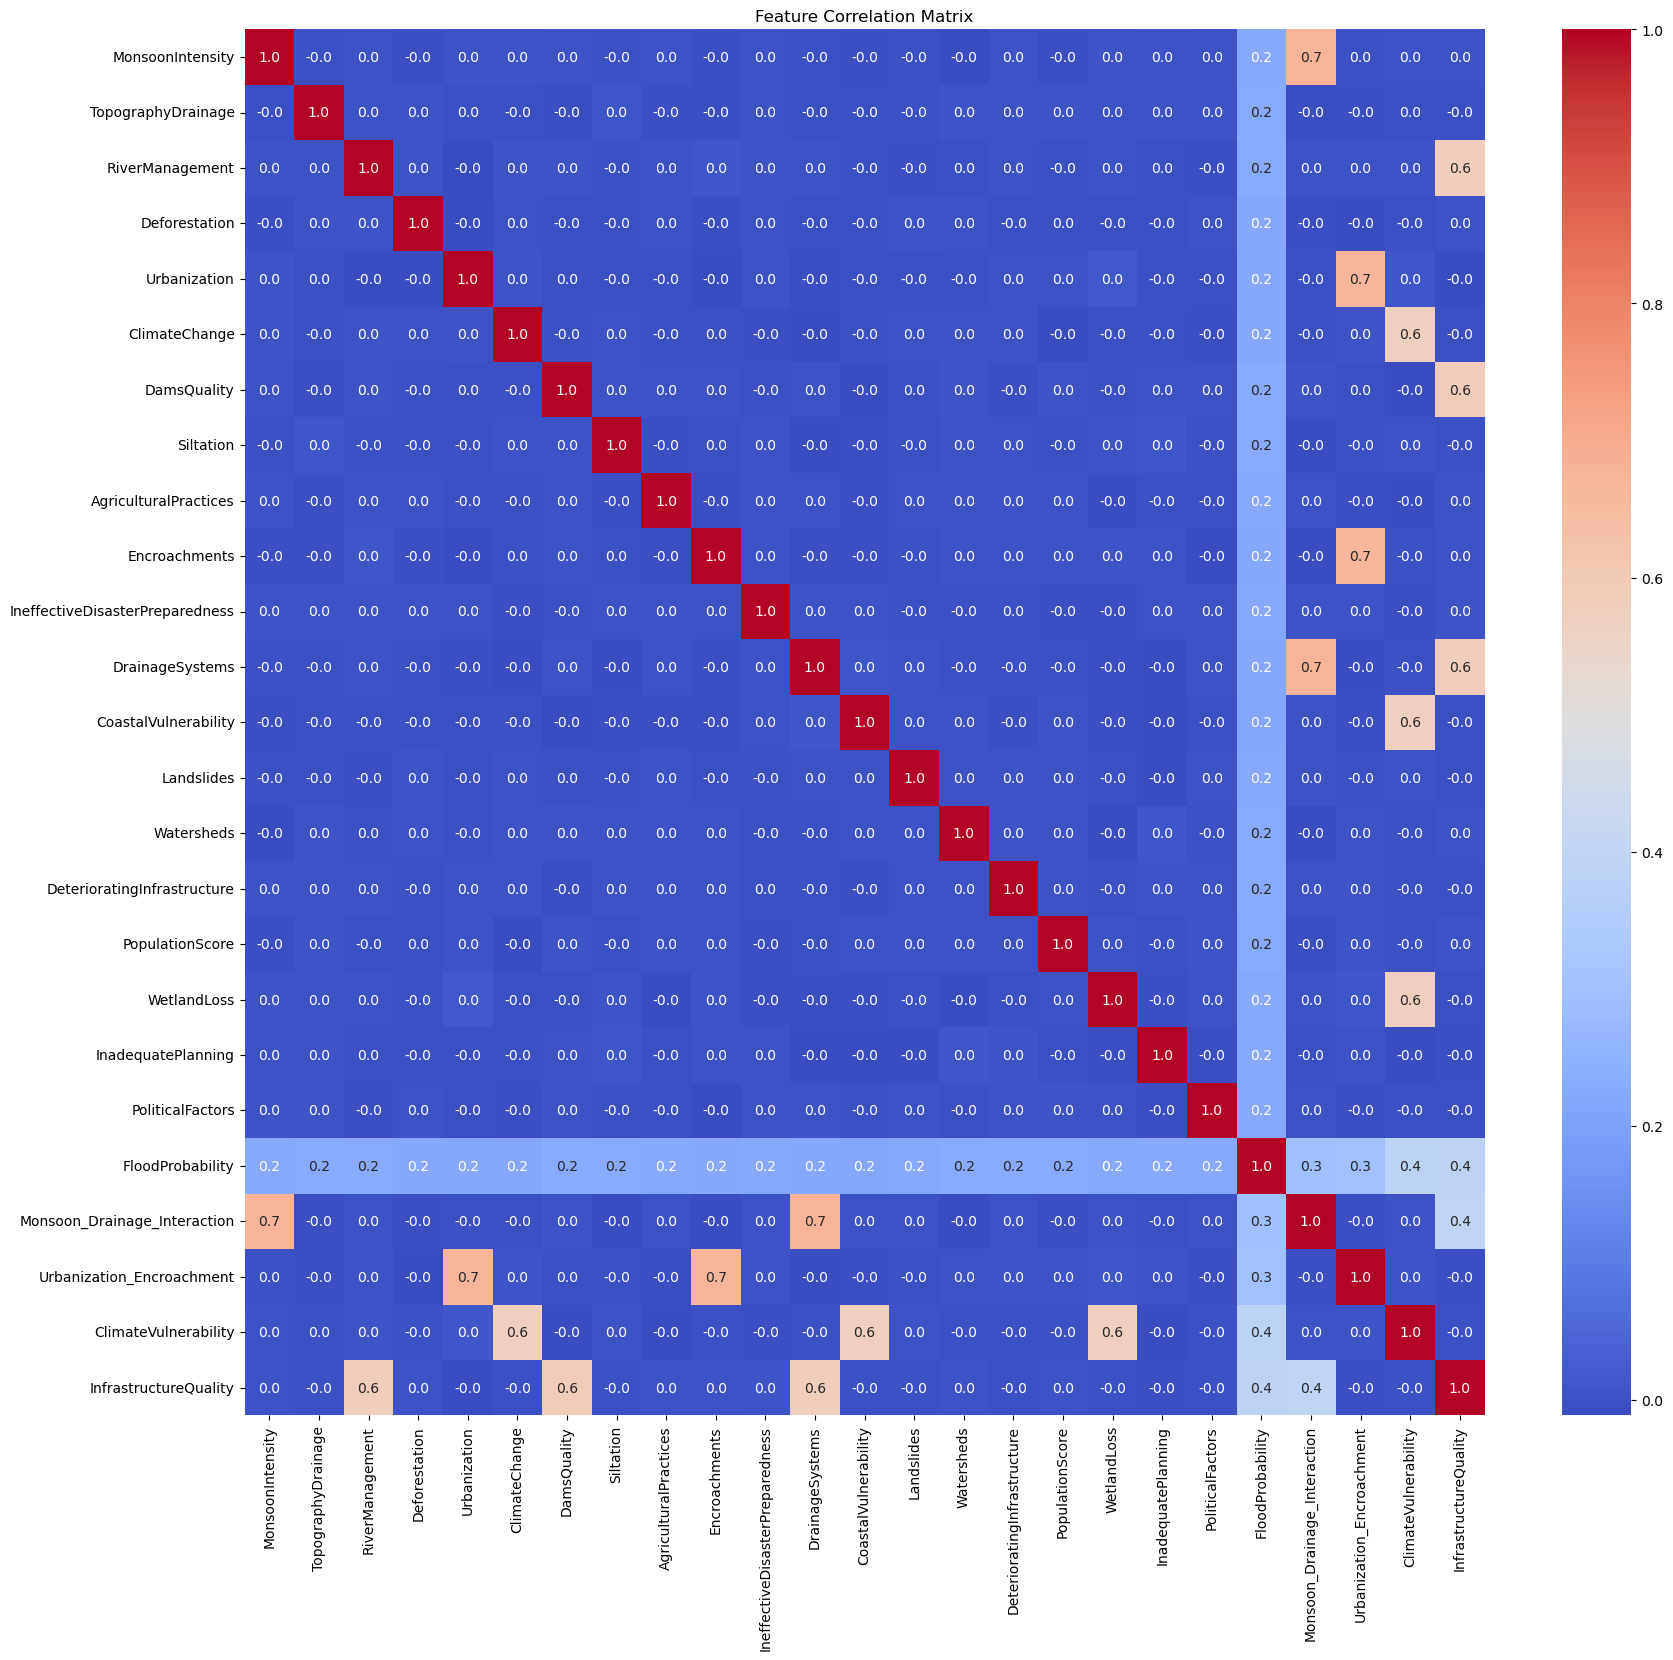

Top features by correlation:
 FloodProbability                1.000000
InfrastructureQuality           0.387482
ClimateVulnerability            0.382139
Urbanization_Encroachment       0.297995
Monsoon_Drainage_Interaction    0.296578
DeterioratingInfrastructure     0.229444
TopographyDrainage              0.229414
RiverManagement                 0.228917
Watersheds                      0.228152
DamsQuality                     0.227467
Name: FloodProbability, dtype: float64


In [13]:
# ====== CORRELATION ANALYSIS ======
plt.figure(figsize=(20, 18))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# Top features by target correlation
target_corr = corr_matrix['FloodProbability'].abs().sort_values(ascending=False)
print("Top features by correlation:\n", target_corr.head(10))


In [ ]:

# ====== DATA SPLITTING ======
# from sklearn.model_selection import train_test_split

X = df.drop('FloodProbability', axis=1)
y = df['FloodProbability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:

# ==== Model Comparison ====
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

# Define RMSE scorer
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
                          greater_is_better=False)

models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Support Vector Machine': SVR(C=1.0, kernel='rbf'),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

results = []
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    rmse = -cross_val_score(pipeline, X_train, y_train, cv=5, scoring=rmse_scorer).mean()
    r2 = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2').mean()
    results.append((name, rmse, r2))
    print(f"{name}: RMSE = {rmse:.4f}, R² = {r2:.4f}")

# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'R2']).sort_values(by='RMSE')
print("\nModel Comparison Summary:")
print(comparison_df)

# Select best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest Model Selected: {best_model_name}")

# Retrain best model
final_model = models[best_model_name]
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', final_model)
])
final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

# Evaluate final model
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)
print(f"Final Model Performance - RMSE: {final_rmse:.4f}, R²: {final_r2:.4f}")


In [ ]:
# ====== FEATURE IMPORTANCE ======
# For Ridge Regression, use absolute value of coefficients as importance
importances = np.abs(final_pipeline.named_steps['model'].coef_)
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15])
plt.title('Top 15 Feature Importances (Ridge Coefficients)')
plt.show()

In [ ]:
# ==== Flood Probability Categorization ====
def categorize_risk(prob):
    if prob < 0.3:
        return 'Low'
    elif prob < 0.6:
        return 'Moderate'
    else:
        return 'High'

# Apply categorization to predictions
y_test_cat = y_test.apply(categorize_risk)
y_pred_cat = pd.Series(y_pred).apply(categorize_risk)

# Classification report
from sklearn.metrics import confusion_matrix, classification_report
print("Confusion Matrix:")
print(confusion_matrix(y_test_cat, y_pred_cat))
print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_cat))
